In [1]:
import yfinance as yf
import pandas as pd
import os

# ---------- Step 0: Config ----------
ticker = '^NSEI'
start_date = '2014-01-01'
end_date = '2023-12-31'
output_path = 'datamaster_project2/raw'
output_file = os.path.join(output_path, 'nifty50.csv')

# ---------- Step 1: Create directory if it doesn't exist ----------
os.makedirs(output_path, exist_ok=True)

# ---------- Step 2: Fetch data from Yahoo Finance ----------
nifty = yf.download(ticker, start=start_date, end=end_date)

# ---------- Step 3: Keep only 'Close' and save as CSV ----------
nifty[['Close']].dropna().to_csv(output_file)

# ---------- Step 4: Confirm ----------
print(f"✅ NIFTY 50 data saved to: {output_file}")
print(nifty[['Close']].dropna().head())


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

✅ NIFTY 50 data saved to: datamaster_project2/raw\nifty50.csv
Price             Close
Ticker            ^NSEI
Date                   
2014-01-02  6221.149902
2014-01-03  6211.149902
2014-01-06  6191.450195
2014-01-07  6162.250000
2014-01-08  6174.600098


In [3]:
import pandas as pd

# Load the CSV
csv_path = 'datamaster_project2/raw/nifty50.csv'
df = pd.read_csv(csv_path)

# Define Excel path
excel_path = 'datamaster_project2/raw/nifty50.xlsx'

# Save as Excel
df.to_excel(excel_path, index=False)

print(f"✅ Excel version saved to: {excel_path}")


✅ Excel version saved to: datamaster_project2/raw/nifty50.xlsx


In [5]:
import pandas as pd
import os

# ---------- Step 1: Load Raw Data ----------
raw_path = 'datamaster_project2/raw/nifty50.csv'
df = pd.read_csv(raw_path)

# ---------- Step 2: Parse Date, Set as Index, Sort ----------
df['Date'] = pd.to_datetime(df['Date'])     # Ensure proper datetime format
df.set_index('Date', inplace=True)          # Make Date the index
df = df.sort_index()                        # Sort by date in ascending order

# ---------- Step 3: Keep Only 'Close' and Drop Missing ----------
df = df[['Close']].copy()
df = df.dropna()

# ---------- Step 4: Final Check ----------
print("Date Range:", df.index.min(), "to", df.index.max())
print("Total Records:", len(df))
print("Missing values:", df.isnull().sum().sum())

# ---------- Step 5: Save Cleaned Data ----------
output_dir = 'datamaster_project2/clean'
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, 'nifty50_clean.csv')
excel_path = os.path.join(output_dir, 'nifty50_clean.xlsx')

df.to_csv(csv_path)
df.to_excel(excel_path)

print(f"✅ Cleaned CSV saved to: {csv_path}")
print(f"✅ Cleaned Excel saved to: {excel_path}")


KeyError: 'Date'

In [7]:
import pandas as pd
import os

# ---------- Step 1: Load the Excel ----------
df = pd.read_excel('datamaster_project2/raw/nifty50.xlsx')

# ---------- Step 2: Ensure Date format, Set Index, Sort ----------
df['Date'] = pd.to_datetime(df['Date'])           # Make sure 'Date' column is datetime
df = df[['Date', 'Close']].dropna()               # Keep only Date and Close
df = df.sort_values('Date')                       # Sort by Date
df.set_index('Date', inplace=True)

# ---------- Step 3: Sanity Checks ----------
print("Date Range:", df.index.min(), "to", df.index.max())
print("Total Records:", len(df))
print("Missing values:", df.isnull().sum().sum())

# ---------- Step 4: Save Cleaned Data ----------
output_dir = 'datamaster_project2/clean'
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, 'nifty50_clean.csv')
excel_path = os.path.join(output_dir, 'nifty50_clean.xlsx')

df.to_csv(csv_path)
df.to_excel(excel_path)

print(f"✅ Cleaned CSV saved to: {csv_path}")
print(f"✅ Cleaned Excel saved to: {excel_path}")


KeyError: 'Date'

In [9]:
df = pd.read_excel('datamaster_project2/raw/nifty50.xlsx')
print(df.columns)


Index(['Price', 'Close'], dtype='object')


In [11]:
import pandas as pd
import os

# ---------- Load Excel with Date column named 'Price' ----------
df = pd.read_excel('datamaster_project2/raw/nifty50.xlsx')
df.rename(columns={'Price': 'Date'}, inplace=True)

# ---------- Clean and Sort ----------
df['Date'] = pd.to_datetime(df['Date'])       # convert to datetime
df = df[['Date', 'Close']].dropna()           # keep only needed columns
df = df.sort_values('Date')                   # sort by date
df.set_index('Date', inplace=True)            # set date as index

# ---------- Save Cleaned Output ----------
output_dir = 'datamaster_project2/clean'
os.makedirs(output_dir, exist_ok=True)

csv_path = f'{output_dir}/nifty50_clean.csv'
excel_path = f'{output_dir}/nifty50_clean.xlsx'

df.to_csv(csv_path)
df.to_excel(excel_path)

print(f"✅ Cleaned CSV saved to: {csv_path}")
print(f"✅ Cleaned Excel saved to: {excel_path}")


C:\Users\2024a\AppData\Local\Temp\ipykernel_18248\2432258079.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])       # convert to datetime


DateParseError: Unknown datetime string format, unable to parse: Ticker, at position 0

In [13]:
import pandas as pd
import os

# ---------- Step 1: Load & Skip First Two Rows ----------
df = pd.read_excel('datamaster_project2/raw/nifty50.xlsx', skiprows=2)

# ---------- Step 2: Rename Columns ----------
df.columns = ['Date', 'Close']  # Rename first two columns properly

# ---------- Step 3: Clean and Prepare ----------
df['Date'] = pd.to_datetime(df['Date'])       # Convert to datetime
df = df[['Date', 'Close']].dropna()           # Keep only what's needed
df = df.sort_values('Date')                   # Sort by date
df.set_index('Date', inplace=True)            # Set date as index

# ---------- Step 4: Save Cleaned Data ----------
output_dir = 'datamaster_project2/clean'
os.makedirs(output_dir, exist_ok=True)

df.to_csv(f'{output_dir}/nifty50_clean.csv')
df.to_excel(f'{output_dir}/nifty50_clean.xlsx')

print("✅ Cleaned data saved to:")
print(f"  CSV: {output_dir}/nifty50_clean.csv")
print(f"  Excel: {output_dir}/nifty50_clean.xlsx")


✅ Cleaned data saved to:
  CSV: datamaster_project2/clean/nifty50_clean.csv
  Excel: datamaster_project2/clean/nifty50_clean.xlsx


In [15]:
import pandas as pd

# Load the cleaned data
df = pd.read_csv('datamaster_project2/clean/nifty50_clean.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Initialize score
score = 10
issues = []

# 1. Check for missing values
if df.isnull().sum().sum() > 0:
    score -= 1
    issues.append("❌ Missing values found")

# 2. Check for datetime index
if not pd.api.types.is_datetime64_any_dtype(df.index):
    score -= 1
    issues.append("❌ Index is not datetime")

# 3. Check chronological order
if not df.index.is_monotonic_increasing:
    score -= 1
    issues.append("❌ Dates not in order")

# 4. Check for duplicate dates
if df.index.duplicated().sum() > 0


SyntaxError: expected ':' (209073627.py, line 27)

In [17]:
import pandas as pd

# Load the cleaned data
df = pd.read_csv('datamaster_project2/clean/nifty50_clean.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Initialize score
score = 10
issues = []

# 1. Check for missing values
if df.isnull().sum().sum() > 0:
    score -= 1
    issues.append("❌ Missing values found")

# 2. Check for datetime index
if not pd.api.types.is_datetime64_any_dtype(df.index):
    score -= 1
    issues.append("❌ Index is not datetime")

# 3. Check chronological order
if not df.index.is_monotonic_increasing:
    score -= 1
    issues.append("❌ Dates not in order")

# 4. Check for duplicate dates
if df.index.duplicated().sum() > 0:
    score -= 1
    issues.append("❌ Duplicate dates found")

# 5. Check for zero or negative close values
if (df['Close'] <= 0).sum() > 0:
    score -= 1
    issues.append("❌ Close prices with zero or negative values")

# 6. Check for daily frequency
date_diff = df.index.to_series().diff().dropna().dt.days
if not (date_diff == 1).mean() > 0.75:  # allow for weekends/holidays
    score -= 1
    issues.append("❌ Inconsistent daily frequency")

# 7. Check for column structure
expected_cols = ['Close']
if list(df.columns) != expected_cols:
    score -= 1
    issues.append("❌ Columns are not just ['Close']")

# 8. Check sufficient data length
if len(df) < 1000:
    score -= 1
    issues.append("❌ Not enough data points (<1000)")

# 9. Check for outliers (extremely high or low prices)
if df['Close'].max() > 100000 or df['Close'].min() < 100:
    score -= 1
    issues.append("❌ Possible outliers in price range")

# 10. Check index uniqueness
if not df.index.is_unique:
    score -= 1
    issues.append("❌ Index not unique")

# Final Output
print(f"🧼 Data Cleanliness Score: {score}/10")
if score == 10:
    print("✅ All checks passed. Data is clean and ready.")
else:
    print("⚠️ Issues found:")
    for issue in issues:
        print(issue)


🧼 Data Cleanliness Score: 10/10
✅ All checks passed. Data is clean and ready.


In [19]:
import numpy as np
import pandas as pd

# Load the cleaned close prices
df = pd.read_csv('datamaster_project2/clean/nifty50_clean.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Compute log returns
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# Drop the first row (it will have NaN return)
df = df.dropna()

# Preview
print(df.head())


                  Close  Log_Returns
Date                                
2014-01-03  6211.149902    -0.001609
2014-01-06  6191.450195    -0.003177
2014-01-07  6162.250000    -0.004727
2014-01-08  6174.600098     0.002002
2014-01-09  6168.350098    -0.001013


In [21]:
# Save the log-return dataset
output_dir = 'datamaster_project2/clean'
df.to_csv(f'{output_dir}/nifty50_returns.csv')
df.to_excel(f'{output_dir}/nifty50_returns.xlsx')

print("✅ Log returns saved successfully.")


✅ Log returns saved successfully.


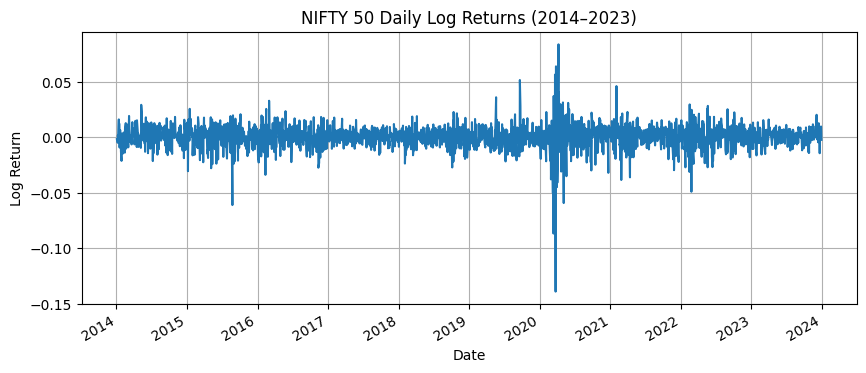

In [23]:
import matplotlib.pyplot as plt

df['Log_Returns'].plot(figsize=(10, 4), title='NIFTY 50 Daily Log Returns (2014–2023)')
plt.ylabel('Log Return')
plt.grid(True)
plt.show()


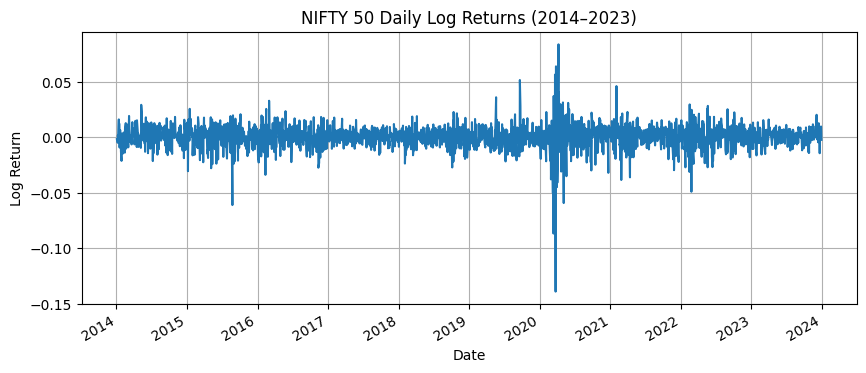

✅ Log return plot saved to: datamaster_project2/clean\nifty50_log_returns.png


In [25]:
import matplotlib.pyplot as plt
import os

# Ensure the clean folder exists
output_dir = 'datamaster_project2/clean'
os.makedirs(output_dir, exist_ok=True)

# Create the plot
plt.figure(figsize=(10, 4))
df['Log_Returns'].plot()
plt.title('NIFTY 50 Daily Log Returns (2014–2023)')
plt.ylabel('Log Return')
plt.grid(True)

# Save the plot as a PNG
plot_path = os.path.join(output_dir, 'nifty50_log_returns.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

print(f"✅ Log return plot saved to: {plot_path}")


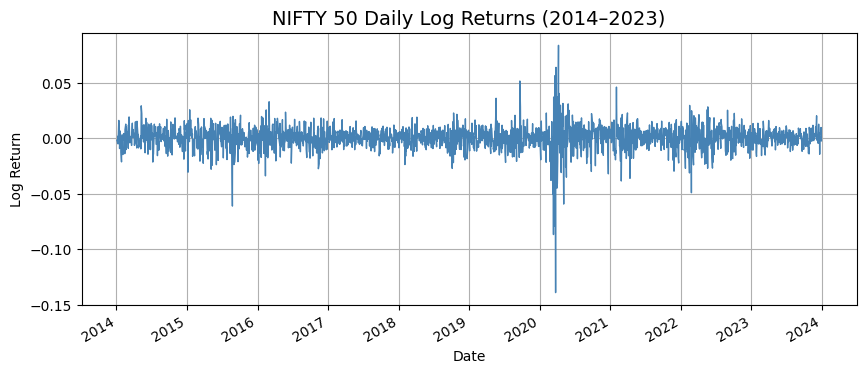

✅ Time-series plot saved to: datamaster_project2/EDA\nifty50_log_returns_timeseries.png


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------- Step 1: Load Returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Create EDA Folder ----------
eda_dir = 'datamaster_project2/EDA'
os.makedirs(eda_dir, exist_ok=True)

# ---------- Step 3: Plot Log Returns ----------
plt.figure(figsize=(10, 4))
df['Log_Returns'].plot(color='steelblue', linewidth=1)
plt.title('NIFTY 50 Daily Log Returns (2014–2023)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)

# ---------- Step 4: Save Plot ----------
plot_path = os.path.join(eda_dir, 'nifty50_log_returns_timeseries.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Time-series plot saved to: {plot_path}")


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------- Step 1: Load log returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Create EDA output directory ----------
eda_dir = 'datamaster_project2/EDA'
os.makedirs(eda_dir, exist_ok=True)

# ---------- Step 3: Plot histogram + KDE ----------
plt.figure(figsize=(10, 5))
sns.histplot(df['Log_Returns'], kde=True, bins=100, color='teal', stat='density')
plt.title('Distribution of NIFTY 50 Daily Log Returns (2014–2023)', fontsize=14)
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.grid(True)

# ---------- Step 4: Save figure ----------
hist_path = os.path.join(eda_dir, 'nifty50_log_returns_hist_kde.png')
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Histogram + KDE saved to: {hist_path}")


ModuleNotFoundError: No module named 'seaborn'

In [31]:
!pip install seaborn


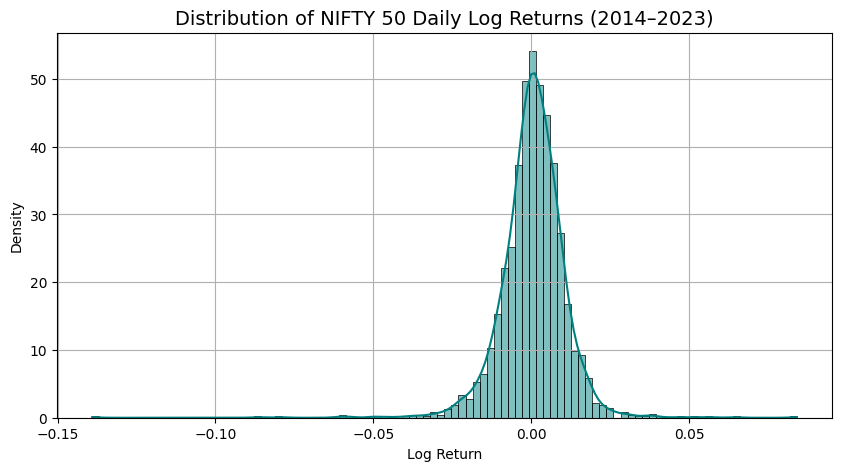

✅ Histogram + KDE saved to: datamaster_project2/EDA\nifty50_log_returns_hist_kde.png


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------- Step 1: Load log returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Create EDA output directory ----------
eda_dir = 'datamaster_project2/EDA'
os.makedirs(eda_dir, exist_ok=True)

# ---------- Step 3: Plot histogram + KDE ----------
plt.figure(figsize=(10, 5))
sns.histplot(df['Log_Returns'], kde=True, bins=100, color='teal', stat='density')
plt.title('Distribution of NIFTY 50 Daily Log Returns (2014–2023)', fontsize=14)
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.grid(True)

# ---------- Step 4: Save figure ----------
hist_path = os.path.join(eda_dir, 'nifty50_log_returns_hist_kde.png')
plt.savefig(hist_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Histogram + KDE saved to: {hist_path}")


In [35]:
import pandas as pd
import os

# ---------- Step 1: Load Log Returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Compute Descriptive Statistics ----------
desc_stats = df['Log_Returns'].describe()

# ---------- Step 3: Create EDA Directory ----------
eda_dir = 'datamaster_project2/EDA'
os.makedirs(eda_dir, exist_ok=True)

# ---------- Step 4: Save to TXT Report ----------
report_path = os.path.join(eda_dir, 'nifty50_log_returns_descriptive_stats.txt')
with open(report_path, 'w') as file:
    file.write("📉 Descriptive Statistics of NIFTY 50 Daily Log Returns (2014–2023)\n")
    file.write("-" * 60 + "\n")
    file.write(desc_stats.to_string())

# ---------- Step 5: Print Output ----------
print("✅ Descriptive statistics saved to:")
print(report_path)
print("\n📋 Summary:")
print(desc_stats)


UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f4c9' in position 0: character maps to <undefined>

In [37]:
import pandas as pd
import os

# ---------- Step 1: Load Log Returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Compute Descriptive Statistics ----------
desc_stats = df['Log_Returns'].describe()

# ---------- Step 3: Create EDA Directory ----------
eda_dir = 'datamaster_project2/EDA'
os.makedirs(eda_dir, exist_ok=True)

# ---------- Step 4: Save to TXT Report (UTF-8 encoding fix) ----------
report_path = os.path.join(eda_dir, 'nifty50_log_returns_descriptive_stats.txt')
with open(report_path, 'w', encoding='utf-8') as file:
    file.write("📉 Descriptive Statistics of NIFTY 50 Daily Log Returns (2014–2023)\n")
    file.write("-" * 60 + "\n")
    file.write(desc_stats.to_string())

# ---------- Step 5: Print Output ----------
print("✅ Descriptive statistics saved to:")
print(report_path)
print("\n📋 Summary:")
print(desc_stats)


✅ Descriptive statistics saved to:
datamaster_project2/EDA\nifty50_log_returns_descriptive_stats.txt

📋 Summary:
count    2452.000000
mean        0.000510
std         0.010484
min        -0.139038
25%        -0.004331
50%         0.000779
75%         0.006120
max         0.084003
Name: Log_Returns, dtype: float64


In [39]:
import pandas as pd
import os
from scipy.stats import skew, kurtosis

# ---------- Step 1: Load Log Returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Calculate Skewness & Kurtosis ----------
skw = skew(df['Log_Returns'])
krt = kurtosis(df['Log_Returns'], fisher=False)  # Use Pearson’s definition (Normal = 3)

# ---------- Step 3: Prepare Summary Text ----------
report_text = (
    "🔀 Skewness and Kurtosis of NIFTY 50 Daily Log Returns (2014–2023)\n"
    + "-" * 60 + "\n"
    + f"Skewness: {skw:.4f}  --> {'Positive' if skw > 0 else 'Negative'} skew\n"
    + f"Kurtosis: {krt:.4f}  --> {'Leptokurtic (Fat-tailed)' if krt > 3 else 'Platykurtic (Thin-tailed)'}"
)

# ---------- Step 4: Save Report ----------
eda_dir = 'datamaster_project2/EDA'
os.makedirs(eda_dir, exist_ok=True)

report_path = os.path.join(eda_dir, 'nifty50_log_returns_skew_kurtosis.txt')
with open(report_path, 'w', encoding='utf-8') as file:
    file.write(report_text)

# ---------- Step 5: Print Summary ----------
print("✅ Skewness & Kurtosis saved to:", report_path)
print("\n📋 Summary:")
print(report_text)


✅ Skewness & Kurtosis saved to: datamaster_project2/EDA\nifty50_log_returns_skew_kurtosis.txt

📋 Summary:
🔀 Skewness and Kurtosis of NIFTY 50 Daily Log Returns (2014–2023)
------------------------------------------------------------
Skewness: -1.3762  --> Negative skew
Kurtosis: 23.4782  --> Leptokurtic (Fat-tailed)


In [41]:
import pandas as pd
from scipy.stats import normaltest
import os

# ---------- Step 1: Load Log Returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Perform D’Agostino & Pearson Test ----------
stat, p_value = normaltest(df['Log_Returns'])

# ---------- Step 3: Interpret Result ----------
if p_value > 0.05:
    result_text = "✅ The null hypothesis of normality is NOT rejected (p > 0.05). Returns may be normally distributed."
else:
    result_text = "❌ The null hypothesis of normality is REJECTED (p ≤ 0.05). Returns are NOT normally distributed."

report_text = (
    "🧪 Normality Test (D’Agostino & Pearson) – NIFTY 50 Log Returns\n"
    + "-" * 60 + "\n"
    + f"Test Statistic: {stat:.4f}\n"
    + f"p-value: {p_value:.4f}\n"
    + result_text
)

# ---------- Step 4: Save Report ----------
eda_dir = 'datamaster_project2/EDA'
os.makedirs(eda_dir, exist_ok=True)

report_path = os.path.join(eda_dir, 'nifty50_log_returns_normality_test.txt')
with open(report_path, 'w', encoding='utf-8') as file:
    file.write(report_text)

# ---------- Step 5: Print Summary ----------
print("✅ Normality test result saved to:", report_path)
print("\n📋 Summary:")
print(report_text)


✅ Normality test result saved to: datamaster_project2/EDA\nifty50_log_returns_normality_test.txt

📋 Summary:
🧪 Normality Test (D’Agostino & Pearson) – NIFTY 50 Log Returns
------------------------------------------------------------
Test Statistic: 1078.9308
p-value: 0.0000
❌ The null hypothesis of normality is REJECTED (p ≤ 0.05). Returns are NOT normally distributed.


In [43]:
import pandas as pd
import numpy as np
import os

# ---------- Step 1: Load log returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Set 99% confidence Z-score ----------
z_score = 2.326

# ---------- Step 3: Compute constant volatility ----------
sigma = df['Log_Returns'].std()

# ---------- Step 4: Calculate 1-day VCV VaR ----------
df['VaR_VCV'] = -z_score * sigma

# ---------- Step 5: Save to correct folder ----------
vcv_path = 'datamaster_project2/1_Variance–Covariance_Method'
os.makedirs(vcv_path, exist_ok=True)

df.to_csv(os.path.join(vcv_path, 'nifty50_returns_with_var_vcv.csv'))
df.to_excel(os.path.join(vcv_path, 'nifty50_returns_with_var_vcv.xlsx'))

print("✅ VCV VaR (99%) successfully computed and saved to:")
print(f"   📄 CSV: {vcv_path}/nifty50_returns_with_var_vcv.csv")
print(f"   📊 Excel: {vcv_path}/nifty50_returns_with_var_vcv.xlsx")
print(f"📉 Daily VaR estimate: {df['VaR_VCV'].iloc[0]:.4f}")


✅ VCV VaR (99%) successfully computed and saved to:
   📄 CSV: datamaster_project2/1_Variance–Covariance_Method/nifty50_returns_with_var_vcv.csv
   📊 Excel: datamaster_project2/1_Variance–Covariance_Method/nifty50_returns_with_var_vcv.xlsx
📉 Daily VaR estimate: -0.0244


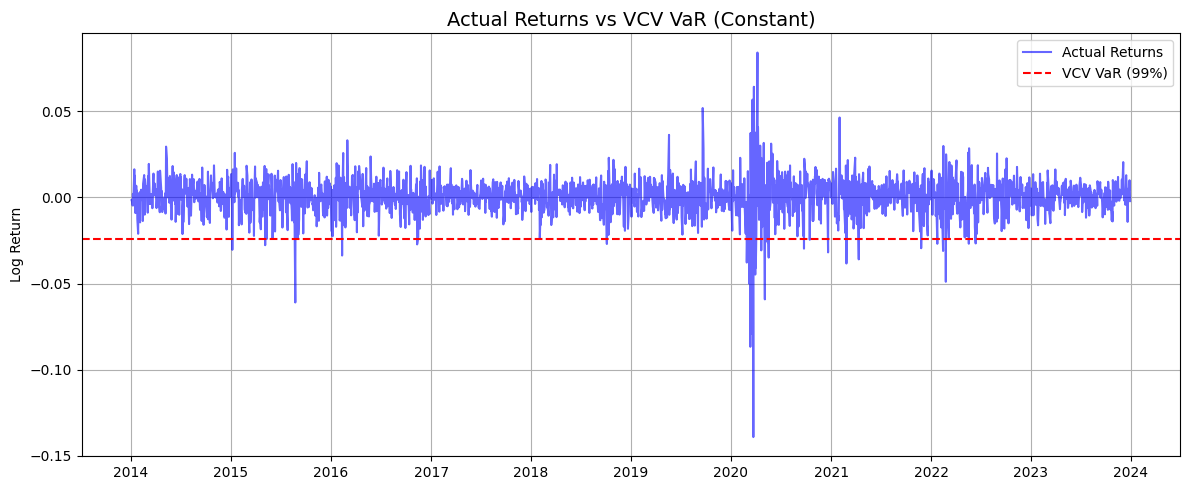

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Log_Returns'], label='Actual Returns', color='blue', alpha=0.6)
plt.axhline(y=df['VaR_VCV'].iloc[0], color='red', linestyle='--', label='VCV VaR (99%)')

plt.title('Actual Returns vs VCV VaR (Constant)', fontsize=14)
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


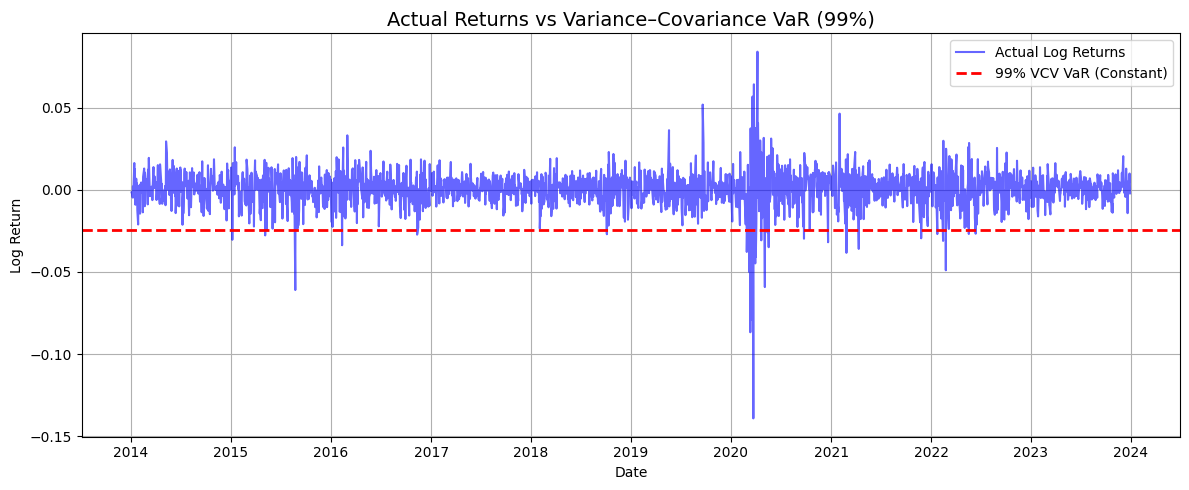

✅ Plot saved to: datamaster_project2/1_Variance–Covariance_Method\nifty50_vcv_var_plot.png


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------- Step 1: Load data with VCV VaR ----------
vcv_path = 'datamaster_project2/1_Variance–Covariance_Method'
df = pd.read_csv(os.path.join(vcv_path, 'nifty50_returns_with_var_vcv.csv'), parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: Plot Actual Returns vs VCV VaR Line ----------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Log_Returns'], label='Actual Log Returns', color='blue', alpha=0.6)
plt.axhline(y=df['VaR_VCV'].iloc[0], color='red', linestyle='--', linewidth=2, label='99% VCV VaR (Constant)')

plt.title('Actual Returns vs Variance–Covariance VaR (99%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()

# ---------- Step 3: Save Plot ----------
plot_path = os.path.join(vcv_path, 'nifty50_vcv_var_plot.png')
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"✅ Plot saved to: {plot_path}")


✅ EWMA VaR and Volatility saved successfully.


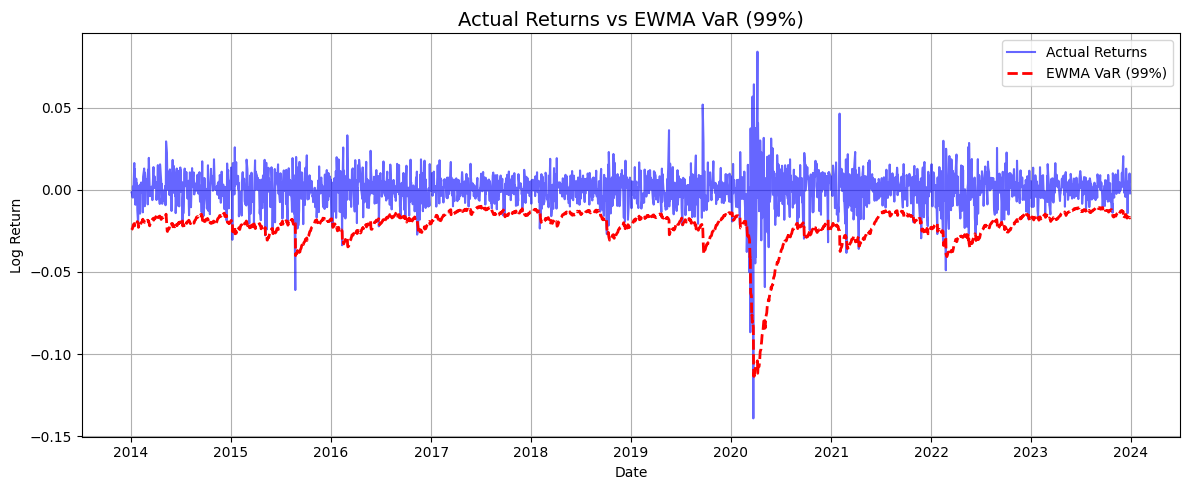

📉 EWMA VaR plot saved to: datamaster_project2/2_EWMA_Method\nifty50_ewma_var_plot.png


In [49]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ---------- Step 1: Load cleaned log return data ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# ---------- Step 2: EWMA configuration ----------
lambda_ = 0.94                      # Decay factor
z_score = 2.326                     # 99% confidence level

# ---------- Step 3: Initialize arrays ----------
returns = df['Log_Returns'].values
n = len(returns)
sigma_squared = np.zeros(n)

# Initialize σ₁² with full-sample variance
sigma_squared[0] = np.var(returns)

# ---------- Step 4: Recursively compute EWMA volatility ----------
for t in range(1, n):
    sigma_squared[t] = lambda_ * sigma_squared[t-1] + (1 - lambda_) * returns[t-1]**2

# Final daily volatility series
sigma = np.sqrt(sigma_squared)

# ---------- Step 5: Compute EWMA VaR (99%) ----------
ewma_var = -z_score * sigma

# ---------- Step 6: Store in DataFrame ----------
df['EWMA_Volatility'] = sigma
df['VaR_EWMA'] = ewma_var

# ---------- Step 7: Save outputs ----------
ewma_path = 'datamaster_project2/2_EWMA_Method'
os.makedirs(ewma_path, exist_ok=True)

df.to_csv(os.path.join(ewma_path, 'nifty50_returns_with_var_ewma.csv'))
df.to_excel(os.path.join(ewma_path, 'nifty50_returns_with_var_ewma.xlsx'))

print("✅ EWMA VaR and Volatility saved successfully.")

# ---------- Step 8: Plot actual returns vs EWMA VaR ----------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Log_Returns'], label='Actual Returns', color='blue', alpha=0.6)
plt.plot(df.index, df['VaR_EWMA'], label='EWMA VaR (99%)', color='red', linestyle='--', linewidth=2)
plt.title('Actual Returns vs EWMA VaR (99%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the plot
plot_path = os.path.join(ewma_path, 'nifty50_ewma_var_plot.png')
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📉 EWMA VaR plot saved to: {plot_path}")


In [51]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from arch import arch_model

# ---------- Step 1: Load log returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

returns = df['Log_Returns'] * 100  # GARCH typically expects returns in percentage form

# ---------- Step 2: Fit GARCH(1,1) Model ----------
model = arch_model(returns, vol='GARCH', p=1, q=1, dist='normal')
garch_result = model.fit(disp='off')

# ---------- Step 3: Get Conditional Volatility (σₜ) ----------
conditional_vol = garch_result.conditional_volatility / 100  # Convert back to decimal scale

# ---------- Step 4: Compute 99% VaR ----------
z_99 = 2.326
var_99 = -z_99 * conditional_vol

# ---------- Step 5: Store results ----------
df['GARCH_Volatility'] = conditional_vol
df['VaR_GARCH'] = var_99

output_path = 'datamaster_project2/3_GARCH_Method'
os.makedirs(output_path, exist_ok=True)

df.to_csv(os.path.join(output_path, 'nifty50_returns_with_var_garch.csv'))
df.to_excel(os.path.join(output_path, 'nifty50_returns_with_var_garch.xlsx'))

print("✅ GARCH VaR and Volatility saved.")

# ---------- Step 6: Plot ----------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Log_Returns'], label='Actual Returns', color='blue', alpha=0.6)
plt.plot(df.index, df['VaR_GARCH'], label='GARCH(1,1) VaR (99%)', color='red', linestyle='--', linewidth=2)
plt.title('Actual Returns vs GARCH(1,1) VaR (99%)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()

# ---------- Step 7: Save Plot ----------
plot_path = os.path.join(output_path, 'nifty50_garch_var_plot.png')
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📉 GARCH VaR plot saved to: {plot_path}")


ModuleNotFoundError: No module named 'arch'

In [53]:
!pip install arch


   ---------------------------------------- 0.0/927.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/927.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/927.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/927.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/927.1 kB ? eta -:--:--
   --------------------- ---------------- 524.3/927.1 kB 453.5 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/927.1 kB 453.5 kB/s eta 0:00:01
   -------------------------------- ----- 786.4/927.1 kB 541.6 kB/s eta 0:00:01
   -------------------------------------- 927.1/927.1 kB 583.3 kB/s eta 0:00:00


✅ GARCH VaR and Volatility saved.


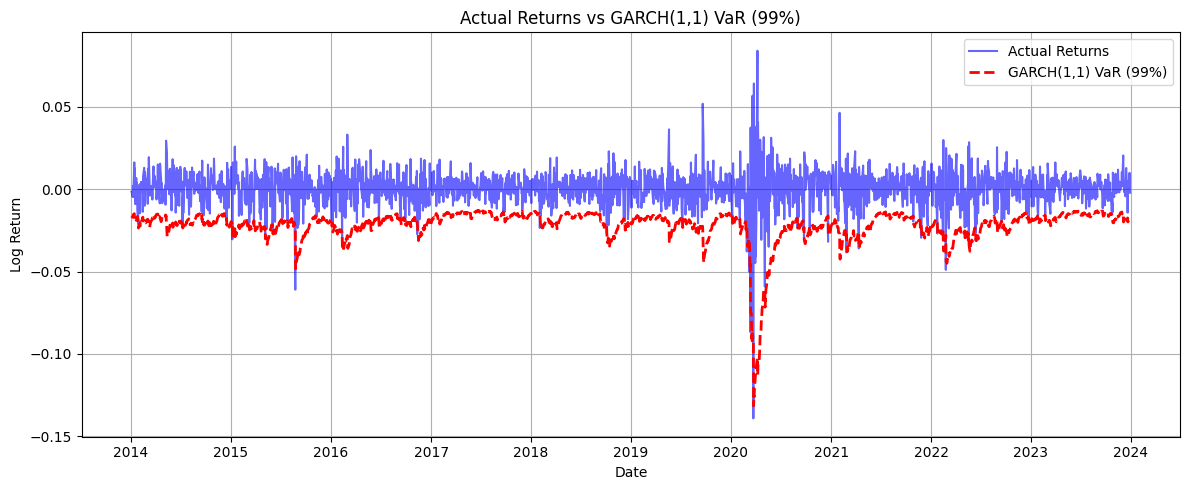

📉 GARCH VaR plot saved to: datamaster_project2/3_GARCH_Method\nifty50_garch_var_plot.png


In [55]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from arch import arch_model

# ---------- Step 1: Load log returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

returns = df['Log_Returns'] * 100  # GARCH typically expects returns in percentage form

# ---------- Step 2: Fit GARCH(1,1) Model ----------
model = arch_model(returns, vol='GARCH', p=1, q=1, dist='normal')
garch_result = model.fit(disp='off')

# ---------- Step 3: Get Conditional Volatility (σₜ) ----------
conditional_vol = garch_result.conditional_volatility / 100  # Convert back to decimal scale

# ---------- Step 4: Compute 99% VaR ----------
z_99 = 2.326
var_99 = -z_99 * conditional_vol

# ---------- Step 5: Store results ----------
df['GARCH_Volatility'] = conditional_vol
df['VaR_GARCH'] = var_99

output_path = 'datamaster_project2/3_GARCH_Method'
os.makedirs(output_path, exist_ok=True)

df.to_csv(os.path.join(output_path, 'nifty50_returns_with_var_garch.csv'))
df.to_excel(os.path.join(output_path, 'nifty50_returns_with_var_garch.xlsx'))

print("✅ GARCH VaR and Volatility saved.")

# ---------- Step 6: Plot ----------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Log_Returns'], label='Actual Returns', color='blue', alpha=0.6)
plt.plot(df.index, df['VaR_GARCH'], label='GARCH(1,1) VaR (99%)', color='red', linestyle='--', linewidth=2)
plt.title('Actual Returns vs GARCH(1,1) VaR (99%)')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()

# ---------- Step 7: Save Plot ----------
plot_path = os.path.join(output_path, 'nifty50_garch_var_plot.png')
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📉 GARCH VaR plot saved to: {plot_path}")


In [57]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ---------- Step 1: Load log returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

returns = df['Log_Returns'].copy()
window_size = 500
confidence_level = 0.99
percentile_cutoff = (1 - confidence_level) * 100  # = 1.0%

# ---------- Step 2: Compute Rolling Historical VaR ----------
historical_var = returns.rolling(window=window_size).quantile(percentile_cutoff)
historical_var.name = 'VaR_HIST'

# Drop first 500 days (no VaR possible)
df = df.iloc[window_size:]
historical_var = historical_var.iloc[window_size:]

# Add to DataFrame
df['VaR_HIST'] = historical_var

# ---------- Step 3: Save to folder ----------
output_path = 'datamaster_project2/4_Historical_Method'
os.makedirs(output_path, exist_ok=True)

df.to_csv(os.path.join(output_path, 'nifty50_returns_with_var_historical.csv'))
df.to_excel(os.path.join(output_path, 'nifty50_returns_with_var_historical.xlsx'))

print("✅ Historical VaR saved successfully.")

# ---------- Step 4: Plot ----------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Log_Returns'], label='Actual Returns', color='blue', alpha=0.6)
plt.plot(df.index, df['VaR_HIST'], label='Historical VaR (99%)', color='red', linestyle='--', linewidth=2)
plt.title('Actual Returns vs Historical Simulation VaR (99%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()

# ---------- Step 5: Save plot ----------
plot_path = os.path.join(output_path, 'nifty50_historical_var_plot.png')
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📉 Historical VaR plot saved to: {plot_path}")


ValueError: quantile value 1.0000000000000009 not in [0, 1]

✅ Historical Simulation VaR saved successfully.


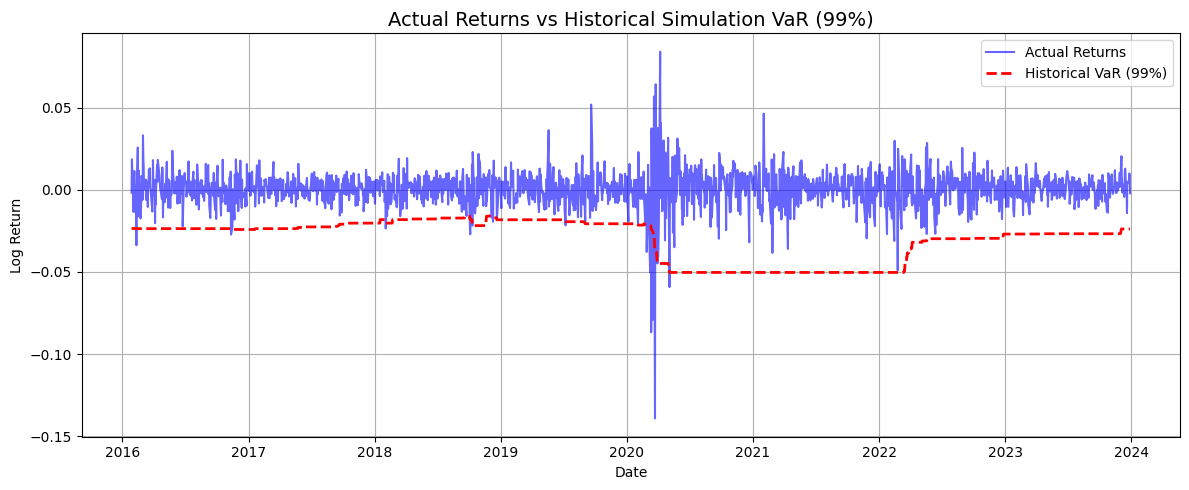

📉 Historical VaR plot saved to: datamaster_project2/4_Historical_Method\nifty50_historical_var_plot.png


In [59]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ---------- Step 1: Load log returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

returns = df['Log_Returns'].copy()
window_size = 500
confidence_level = 0.99
percentile_cutoff = 1 - confidence_level  # = 0.01 for 99% confidence VaR

# ---------- Step 2: Compute Rolling Historical VaR ----------
rolling_var = returns.rolling(window=window_size).quantile(percentile_cutoff)
rolling_var.name = 'VaR_HIST'

# ---------- Step 3: Trim the DataFrame (drop first 500 rows) ----------
df = df.iloc[window_size:].copy()
df['VaR_HIST'] = rolling_var.iloc[window_size:]

# ---------- Step 4: Save Results ----------
output_path = 'datamaster_project2/4_Historical_Method'
os.makedirs(output_path, exist_ok=True)

df.to_csv(os.path.join(output_path, 'nifty50_returns_with_var_historical.csv'))
df.to_excel(os.path.join(output_path, 'nifty50_returns_with_var_historical.xlsx'))

print("✅ Historical Simulation VaR saved successfully.")

# ---------- Step 5: Plot ----------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Log_Returns'], label='Actual Returns', color='blue', alpha=0.6)
plt.plot(df.index, df['VaR_HIST'], label='Historical VaR (99%)', color='red', linestyle='--', linewidth=2)
plt.title('Actual Returns vs Historical Simulation VaR (99%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()

# ---------- Step 6: Save Plot ----------
plot_path = os.path.join(output_path, 'nifty50_historical_var_plot.png')
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📉 Historical VaR plot saved to: {plot_path}")


✅ Monte Carlo VaR saved successfully.


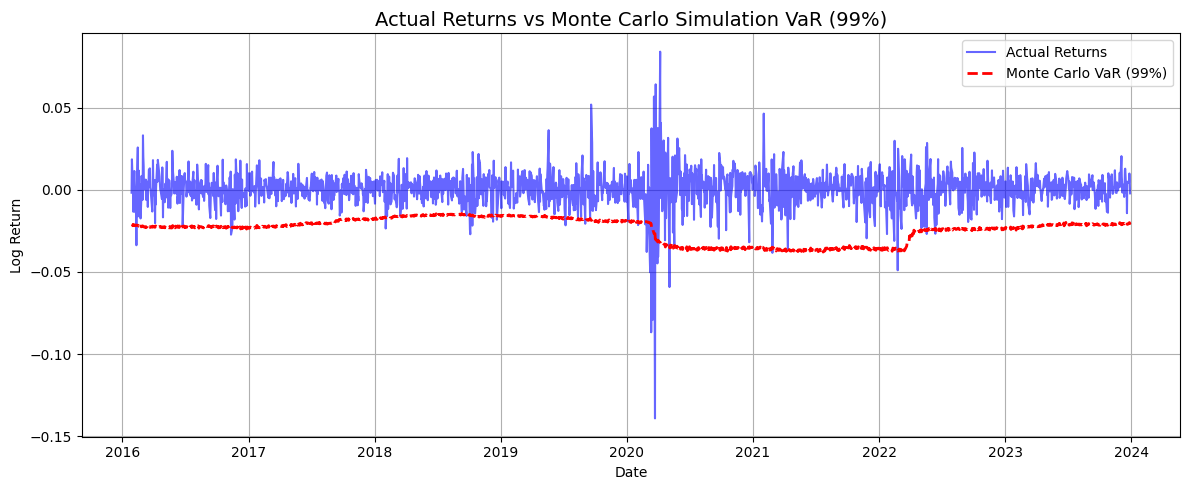

📉 Monte Carlo VaR plot saved to: datamaster_project2/5_MonteCarlo_Method\nifty50_mc_var_plot.png


In [61]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ---------- Step 1: Load log returns ----------
df = pd.read_csv('datamaster_project2/clean/nifty50_returns.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
returns = df['Log_Returns'].copy()

# ---------- Step 2: Set Monte Carlo Parameters ----------
window_size = 500
num_simulations = 10000
confidence_level = 0.99
percentile_cutoff = 1 - confidence_level  # 1% for 99% VaR

# ---------- Step 3: Initialize results ----------
montecarlo_var = []

# ---------- Step 4: Rolling Simulation Loop ----------
for i in range(window_size, len(returns)):
    window = returns.iloc[i - window_size:i]
    mu = window.mean()
    sigma = window.std()

    # Simulate 10,000 future returns
    shocks = np.random.normal(loc=0, scale=1, size=num_simulations)
    simulated_returns = mu + sigma * shocks

    # Compute 1% quantile (VaR at 99% confidence)
    var = np.percentile(simulated_returns, 100 * percentile_cutoff)
    montecarlo_var.append(var)

# ---------- Step 5: Finalize DataFrame ----------
df = df.iloc[window_size:].copy()
df['VaR_MC'] = montecarlo_var

# ---------- Step 6: Save Results ----------
output_path = 'datamaster_project2/5_MonteCarlo_Method'
os.makedirs(output_path, exist_ok=True)

df.to_csv(os.path.join(output_path, 'nifty50_returns_with_var_mc.csv'))
df.to_excel(os.path.join(output_path, 'nifty50_returns_with_var_mc.xlsx'))

print("✅ Monte Carlo VaR saved successfully.")

# ---------- Step 7: Plot ----------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Log_Returns'], label='Actual Returns', color='blue', alpha=0.6)
plt.plot(df.index, df['VaR_MC'], label='Monte Carlo VaR (99%)', color='red', linestyle='--', linewidth=2)
plt.title('Actual Returns vs Monte Carlo Simulation VaR (99%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()

# ---------- Step 8: Save Plot ----------
plot_path = os.path.join(output_path, 'nifty50_mc_var_plot.png')
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"📉 Monte Carlo VaR plot saved to: {plot_path}")


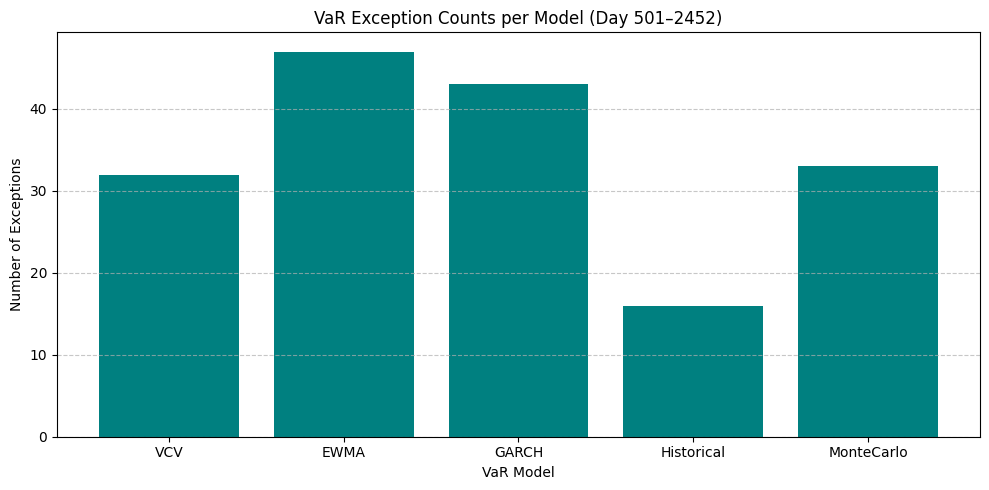

,Model,Total Observations,Exceptions,Exception Rate (%)
0,VCV,2452,32,1.305
1,EWMA,2452,47,1.917
2,GARCH,2452,43,1.754
3,Historical,1952,16,0.820
4,MonteCarlo,1952,33,1.691


In [63]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Step 1: Define base path
base_path = "datamaster_project2"
backtest_path = os.path.join(base_path, "backtesting")
os.makedirs(backtest_path, exist_ok=True)

# Step 2: Define function to load .csv files
def load_var_csv(path, var_column):
    df = pd.read_csv(os.path.join(base_path, path), parse_dates=['Date'])
    df = df[['Date', 'Log_Returns', var_column]].dropna()
    df.set_index('Date', inplace=True)
    return df.rename(columns={var_column: 'VaR'})

# Step 3: File mapping for all models
models = {
    'VCV': ('1_Variance_Covariance_Method/nifty50_returns_with_var_vcv.csv', 'VaR_VCV'),
    'EWMA': ('2_EWMA_Method/nifty50_returns_with_var_ewma.csv', 'VaR_EWMA'),
    'GARCH': ('3_GARCH_Method/nifty50_returns_with_var_garch.csv', 'VaR_GARCH'),
    'Historical': ('4_Historical_Method/nifty50_returns_with_var_historical.csv', 'VaR_HIST'),
    'MonteCarlo': ('5_MonteCarlo_Method/nifty50_returns_with_var_mc.csv', 'VaR_MC'),
}

# Step 4: Exception computation
exception_summary = []

for model, (file_path, var_column) in models.items():
    df = load_var_csv(file_path, var_column)
    df = df.loc[df.index >= df.index[0]]  # already aligned from Day 501 onward
    df['Exception'] = df['Log_Returns'] < df['VaR']
    total_obs = len(df)
    total_exceptions = df['Exception'].sum()
    exception_rate = (total_exceptions / total_obs) * 100

    exception_summary.append({
        'Model': model,
        'Total Observations': total_obs,
        'Exceptions': int(total_exceptions),
        'Exception Rate (%)': round(exception_rate, 3)
    })

# Step 5: Save summary
summary_df = pd.DataFrame(exception_summary)
summary_df.to_csv(os.path.join(backtest_path, 'exception_summary.csv'), index=False)
summary_df.to_excel(os.path.join(backtest_path, 'exception_summary.xlsx'), index=False)

# Step 6: Plot
plt.figure(figsize=(10, 5))
plt.bar(summary_df['Model'], summary_df['Exceptions'], color='teal')
plt.title('VaR Exception Counts per Model (Day 501–2452)')
plt.xlabel('VaR Model')
plt.ylabel('Number of Exceptions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(backtest_path, 'exception_bar_plot.png'), dpi=300)
plt.show()

# Step 7: Show result in notebook
summary_df


In [65]:
import pandas as pd
import numpy as np
import os
from scipy.stats import binom, chi2, norm
import matplotlib.pyplot as plt

# Step 1: Load the exception summary
backtest_path = "datamaster_project2/backtesting"
summary_path = os.path.join(backtest_path, "exception_summary.csv")
df = pd.read_csv(summary_path)

# Step 2: Define expected parameters
N = 1952  # Total days used for backtesting
p = 0.01  # Expected exception rate for 99% VaR

# Step 3: Perform Kupiec Test and Z-Test for each model
results = []

for _, row in df.iterrows():
    x = row['Exceptions']
    model = row['Model']
    
    # Kupiec Proportion of Failures (POF) Test
    pi_hat = x / N
    LR = -2 * (np.log(((1 - p)**(N - x)) * (p**x)) - np.log(((1 - pi_hat)**(N - x)) * (pi_hat**x)))
    kupiec_pval = 1 - chi2.cdf(LR, df=1)
    
    # Binomial Z-Test
    z_stat = (x - N * p) / np.sqrt(N * p * (1 - p))
    z_pval = 2 * (1 - norm.cdf(abs(z_stat)))

    results.append({
        'Model': model,
        'Observed Exceptions': x,
        'Expected Exceptions (1%)': round(N * p, 2),
        'Kupiec LR Statistic': round(LR, 4),
        'Kupiec p-value': round(kupiec_pval, 4),
        'Z-Statistic': round(z_stat, 4),
        'Z-Test p-value': round(z_pval, 4),
        'Kupiec Result': 'Reject' if kupiec_pval < 0.05 else 'Fail to Reject',
        'Z-Test Result': 'Reject' if z_pval < 0.05 else 'Fail to Reject'
    })

# Step 4: Save results to file
results_df = pd.DataFrame(results)
results_csv_path = os.path.join(backtest_path, 'statistical_evaluation.csv')
results_excel_path = os.path.join(backtest_path, 'statistical_evaluation.xlsx')
results_df.to_csv(results_csv_path, index=False)
results_df.to_excel(results_excel_path, index=False)

# Step 5: Display output
results_df


,Model,Observed Exceptions,Expected Exceptions (1%),Kupiec LR Statistic,Kupiec p-value,Z-Statistic,Z-Test p-value,Kupiec Result,Z-Test Result
0,VCV,32,19.52,6.7557,0.0093,2.8389,0.0045,Reject,Reject
1,EWMA,47,19.52,28.0312,0.0000,6.2511,0.0000,Reject,Reject
2,GARCH,43,19.52,21.2459,0.0000,5.3412,0.0000,Reject,Reject
3,Historical,16,19.52,0.6832,0.4085,-0.8007,0.4233,Fail to Reject,Fail to Reject
4,MonteCarlo,33,19.52,7.7887,0.0053,3.0664,0.0022,Reject,Reject
